# Week 2 and Week 4: Regularization and Logistic Scaling

This notebook uses the digital marketing conversion dataset for regularized logistic models and scaling checks.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

In [2]:
import os
import kagglehub
path = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")

print(path)
print(os.listdir(path))
import pandas as pd
import os

df_m = pd.read_csv(os.path.join(path, "digital_marketing_campaign_dataset.csv"))
df_m.head()


/Users/riverocel/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1
['digital_marketing_campaign_dataset.csv']


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [3]:
target = "Conversion"

features = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]

data = df_m[[target] + features].dropna()
X = data[features]
y = data[target]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION")

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("ROC AUC:",
      roc_auc_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.88125
ROC AUC: 0.5527313073675413
[[  23  175]
 [  15 1387]]
              precision    recall  f1-score   support

           0       0.61      0.12      0.19       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.88      1600
   macro avg       0.75      0.55      0.57      1600
weighted avg       0.85      0.88      0.84      1600



## Extra Paper Visuals

The conversion classes are not balanced, so this chart is useful context before reading the model scores.

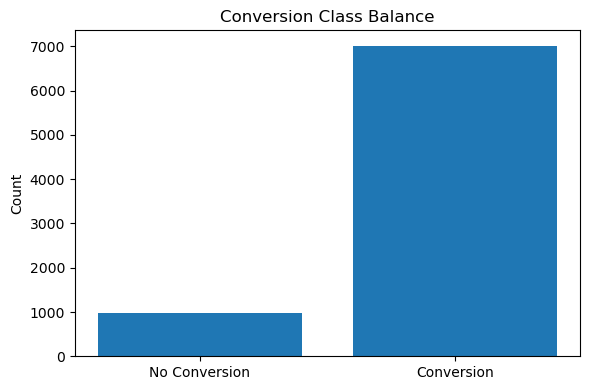

In [5]:
conversion_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Conversion", "Conversion"], conversion_counts.values)
plt.ylabel("Count")
plt.title("Conversion Class Balance")
plt.tight_layout()
plt.show()

for scaled logistic regression on how many people converted, the model is favoring the converted data because it is not balanced.  And we can see that with the recall difference between non converted near 0% accuracy on finding true non converted usage. The ROC curve is just eh anyways.

week 2

In [6]:
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.01,
    class_weight='balanced',
    max_iter=1000
)

lasso_model.fit(X_train_scaled, y_train)

print(lasso_model.coef_)

[[0.         0.         0.28485552 0.34468182 0.14134618 0.20957479
  0.34296736 0.26726848 0.31767926 0.26769239 0.24907127]]


In [7]:
ridge_model = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    C=0.01,
    class_weight='balanced',
    max_iter=1000
)

ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

In [8]:
elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    C=0.01,
    class_weight='balanced',
    max_iter=5000
)

elastic_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, class_weight='balanced', l1_ratio=0.5, max_iter=5000,
                   penalty='elasticnet', solver='saga')

In [9]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Logistic": log_model.coef_[0],
    "Ridge": ridge_model.coef_[0],
    "Lasso": lasso_model.coef_[0],
    "ElasticNet": elastic_model.coef_[0]
})

print(coef_df.round(4))

              Feature  Logistic   Ridge   Lasso  ElasticNet
0                 Age   -0.0140 -0.0062  0.0000      0.0000
1              Income    0.0418  0.0450  0.0000      0.0088
2             AdSpend    0.4361  0.3456  0.2849      0.3232
3    ClickThroughRate    0.4954  0.4136  0.3447      0.3891
4       WebsiteVisits    0.2780  0.2061  0.1413      0.1782
5       PagesPerVisit    0.3715  0.2683  0.2096      0.2444
6          TimeOnSite    0.5074  0.4073  0.3430      0.3851
7          EmailOpens    0.4198  0.3287  0.2673      0.3058
8         EmailClicks    0.4799  0.3823  0.3177      0.3592
9   PreviousPurchases    0.4234  0.3275  0.2677      0.3047
10      LoyaltyPoints    0.3834  0.3179  0.2491      0.2909


largest coefficients are result of logistic regression as we expected as it's the base model, Lasso decreased age and income to 0 shows those variables were not significant in demographic data using feature selection. Elastic net being a mix of both stabilized the variables and shrank them. The strongest variables seemed with AD spend, time on site, email clicks and previous purchases.

week 4

starting with testing different scaling efforts for the dataset.

In [10]:
scaler_options = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scaling_results = []
fitted_scaling_models = {}

for scaler_name, scaler_obj in scaler_options.items():
    steps = []
    if scaler_obj is not None:
        steps.append(("scaler", scaler_obj))

    steps.append((
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    ))

    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    scaling_results.append({
        "Scaling Method": scaler_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "PR AUC": average_precision_score(y_test, y_proba)
    })

    fitted_scaling_models[scaler_name] = pipe

scaling_results_df = pd.DataFrame(scaling_results)
scaling_results_df.round(4)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Scaling Method,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,No Scaling,0.6844,0.6269,0.9172,0.7033,0.7961,0.6751,0.9199
1,StandardScaler,0.7194,0.7119,0.9449,0.7218,0.8184,0.7563,0.9423
2,MinMaxScaler,0.7200,0.7123,0.9450,0.7225,0.8189,0.7563,0.9423
3,RobustScaler,0.7194,0.7119,0.9449,0.7218,0.8184,0.7563,0.9423


## Scaling Method Comparison Chart

This makes the scaler comparison easier to read than just looking across the table.

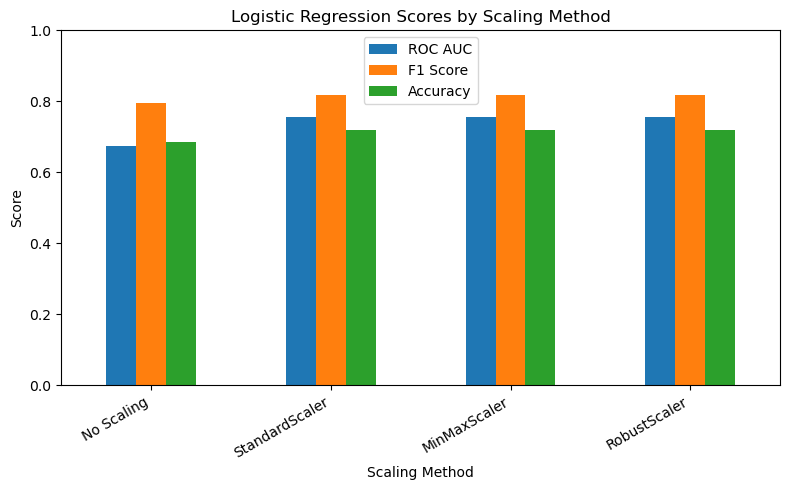

In [11]:
scaling_plot_df = scaling_results_df.set_index("Scaling Method")

scaling_plot_df[["ROC AUC", "F1 Score", "Accuracy"]].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.ylabel("Score")
plt.title("Logistic Regression Scores by Scaling Method")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

the best accuracy came out of minmax scaling! But the rest are also super close vs. no scaling is the worst.

#graph ROC

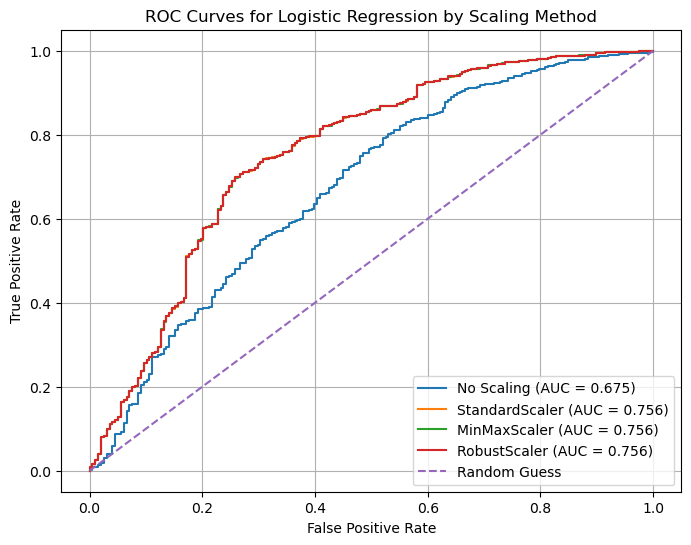

In [12]:
plt.figure(figsize=(8, 6))

for scaler_name, pipe in fitted_scaling_models.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{scaler_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Logistic Regression by Scaling Method")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
best_scaler_name = scaling_results_df.sort_values("ROC AUC", ascending=False).iloc[0]["Scaling Method"]
best_pipe = fitted_scaling_models[best_scaler_name]

best_y_proba = best_pipe.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_y_proba)
f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
best_threshold = thresholds[np.argmax(f1_vals)]

print("Best scaling method:", best_scaler_name)
print("Best F1 threshold:", round(best_threshold, 4))
print("Best F1 score:", round(f1_vals.max(), 4))

threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_vals[:-1],
    "Recall": recall_vals[:-1],
    "F1 Score": f1_vals
})
threshold_df.sort_values("F1 Score", ascending=False).head(10).round(4)

Best scaling method: MinMaxScaler
Best F1 threshold: 0.1739
Best F1 score: 0.9379


,Threshold,Precision,Recall,F1 Score
53,0.1739,0.8940,0.9864,0.9379
50,0.1715,0.8929,0.9872,0.9377
18,0.1266,0.8843,0.9979,0.9377
52,0.1734,0.8934,0.9864,0.9376
20,0.1286,0.8848,0.9971,0.9376
54,0.1800,0.8939,0.9857,0.9376
22,0.1326,0.8853,0.9964,0.9376
88,0.2280,0.9034,0.9743,0.9375
58,0.1847,0.8949,0.9843,0.9375
28,0.1391,0.8868,0.9943,0.9375


to fine tune the threshold and optimize f1 score, I tried multiple thresholds and see their performances.

In [14]:
y_pred_default = (best_y_proba >= 0.50).astype(int)
y_pred_tuned = (best_y_proba >= best_threshold).astype(int)

threshold_comparison = pd.DataFrame([
    {
        "Threshold Type": "Default 0.50",
        "Threshold": 0.50,
        "Accuracy": accuracy_score(y_test, y_pred_default),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default, zero_division=0),
        "Recall": recall_score(y_test, y_pred_default, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_default, zero_division=0)
    },
    {
        "Threshold Type": "Tuned F1 Threshold",
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0)
    }
])

threshold_comparison.round(4)

,Threshold Type,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score
0,Default 0.50,0.5000,0.7200,0.7123,0.945,0.7225,0.8189
1,Tuned F1 Threshold,0.1739,0.8856,0.5791,0.894,0.9864,0.9379


In [15]:
print("Confusion Matrix - Default Threshold")
print(confusion_matrix(y_test, y_pred_default))
print("Confusion Matrix - Tuned Threshold")
print(confusion_matrix(y_test, y_pred_tuned))

Confusion Matrix - Default Threshold
[[ 139   59]
 [ 389 1013]]
Confusion Matrix - Tuned Threshold
[[  34  164]
 [  19 1383]]


the results show for original threshold- the model is fairly conservative. When it predicts someone will convert, it is usually right (high precision), but it misses quite a few actual converters (389 false negatives)

for fine tuned threshold- false negatives dropped a lot, the model now finds almost every customer who actually converts. However false positives increased but it means spending more money on possible customers who are not likely to convert.

next, to show coefficient weights i exponiated the weights  to interpret clearer by binary weights.

In [16]:

final_logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

final_logit_pipe.fit(X_train, y_train)
final_model = final_logit_pipe.named_steps["model"]

coef_interpretation = pd.DataFrame({
    "Feature": features,
    "Coefficient_Log_Odds": final_model.coef_[0],
    "Odds_Ratio": np.exp(final_model.coef_[0])
})

coef_interpretation["Direction"] = np.where(
    coef_interpretation["Odds_Ratio"] > 1,
    "Increases conversion odds",
    "Decreases conversion odds"
)

coef_interpretation.sort_values("Odds_Ratio", ascending=False).round(4)

,Feature,Coefficient_Log_Odds,Odds_Ratio,Direction
3,ClickThroughRate,0.4643,1.5909,Increases conversion odds
6,TimeOnSite,0.4557,1.5772,Increases conversion odds
8,EmailClicks,0.4274,1.5333,Increases conversion odds
2,AdSpend,0.3838,1.4679,Increases conversion odds
7,EmailOpens,0.3655,1.4412,Increases conversion odds
9,PreviousPurchases,0.3623,1.4366,Increases conversion odds
10,LoyaltyPoints,0.3574,1.4296,Increases conversion odds
5,PagesPerVisit,0.2939,1.3417,Increases conversion odds
4,WebsiteVisits,0.2293,1.2577,Increases conversion odds
1,Income,0.0502,1.0515,Increases conversion odds


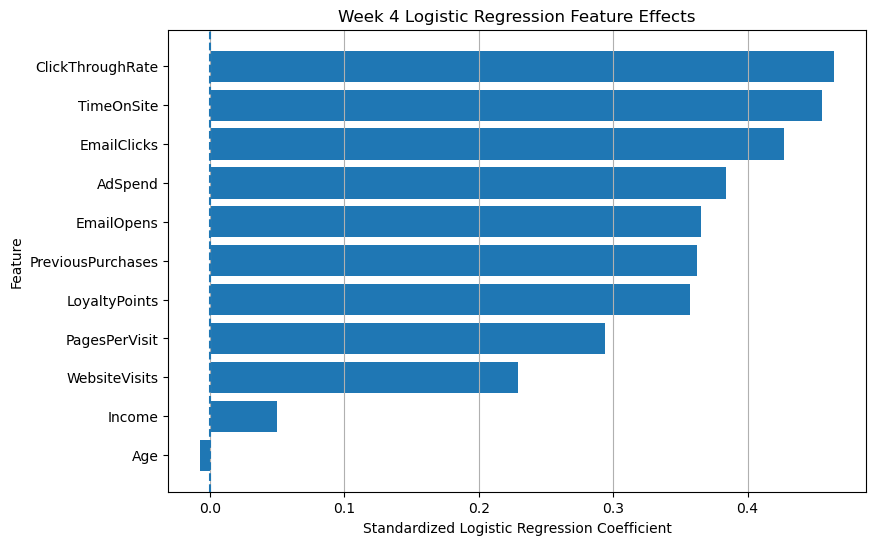

In [17]:
coef_plot_df = coef_interpretation.sort_values("Coefficient_Log_Odds")

plt.figure(figsize=(9, 6))
plt.barh(coef_plot_df["Feature"], coef_plot_df["Coefficient_Log_Odds"])
plt.axvline(0, linestyle="--")
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Week 4 Logistic Regression Feature Effects")
plt.grid(axis="x")
plt.show()

The standardized logistic regression coefficients indicate that customer engagement metrics, particularly Click Through Rate, Time on Site, and Email Clicks, are the strongest predictors of conversion. In contrast, demographic variables such as Age and Income contributed little predictive value. These findings suggest that behavioral interactions with marketing content are more informative for predicting conversion than customer demographics alone.